# 1° Examen Parcial — Correcciones

**Materia**: Simulación de Procesos Financieros  
**Autor**: Francisco Uriel Ledezma Chávez  
**Carrera**: Ingeniería Financiera  
**Fecha**: Octubre de 2026  

En este notebook rehago el primer examen parcial y marco cada corrección con cuatro preguntas, cuál fue el error, cuál es la corrección, por qué lo cometí y cómo puedo evitarlo, de modo que el código corregido y el diagnóstico de cada error puedan revisarse juntos.

Las correcciones 1 y 2 corresponden al problema 1, las correcciones 3 a 5 al problema 2, la corrección 6 a la entrega completa y las correcciones 7 a 9 a los tres problemas del examen escrito.

---

## Importación de Librerías

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

---

## Ingesta de Datos

Ingesto el `.xlsx` y tomo la columna `Día` como índice, de modo que cada rendimiento y cada ventana conserven el día al que corresponden.

In [2]:
Prices = pd.read_excel('data/ex1_01.xlsx', index_col="Día")
Prices

,Ruta A,Ruta B
Día,,
0,100.0,100.0
1,101.2,101.3
2,100.4,99.9
3,102.0,101.8
4,101.5,100.6
5,103.1,102.6
6,102.4,101.4
7,104.2,103.4
8,103.6,102.1


El archivo contiene 60 precios por ruta, del día 0 al 59, y ambas rutas inician en 100 y terminan en 122.40, por lo que solo el camino que recorren puede distinguirlas.

---

## Problema 1

Calculo los rendimientos logarítmicos, que son la base para estimar la volatilidad, y elimino el primer día porque no tiene un precio previo con el cual compararse, con lo que me quedan 59 rendimientos por ruta.

In [3]:
Rendimientos_Logaritmicos = np.log((Prices) / (Prices.shift(1))).dropna()
Rendimientos_Logaritmicos

,Ruta A,Ruta B
Día,,
1,0.011929,0.012916
2,-0.007937,-0.013917
3,0.015811,0.018840
4,-0.004914,-0.011858
5,0.015641,0.019686
6,-0.006813,-0.011765
7,0.017425,0.019532
8,-0.005775,-0.012652
9,0.013423,0.020359


### Corrección 1 — Volatilidad móvil

**¿Cuál fue el error?** Mi ciclo repetía 20 veces `Rendimientos.std() * np.sqrt(252)`, que es la volatilidad de toda la serie, porque el índice `i` no aparecía en el cuerpo del ciclo y además `range(20)` recorría el tamaño de la ventana en lugar de la serie.

**¿Cuál es la corrección?** Dentro del ciclo tomo la ventana `iloc[i:20 + i]` con `i` de 0 a 39, de modo que cada iteración mide 20 rendimientos distintos y obtengo las 40 ventanas que caben en los 59 rendimientos.

**¿Por qué se cometió el error?** Sabía que tenía que recorrer ventanas de 20 días, pero no cómo traducir la ventana de cada día a un rango de posiciones de la serie, por lo que el ciclo me quedó como una repetición del cálculo y no como un recorrido.

**¿Cómo se puede evitar este error en el futuro?** Voy a revisar que la variable de todo ciclo `for` aparezca dentro de su cuerpo y a comprobar, antes de seguir, que el resultado tenga el número esperado de elementos ($59 - 20 + 1 = 40$) y que sus valores cambien entre sí, o bien usaré `.rolling(20)`, que ya define la ventana.

In [4]:
n = 40

Desviaciones = []
for i in range(n):
    Desviaciones_Moviles = Rendimientos_Logaritmicos.iloc[0 + i:20 + i].std() * np.sqrt(252)
    Desviaciones.append(Desviaciones_Moviles)

Desviaciones

[Ruta A    0.181128
 Ruta B    0.251356
 dtype: float64,
 Ruta A    0.182363
 Ruta B    0.257955
 dtype: float64,
 Ruta A    0.181861
 Ruta B    0.256210
 dtype: float64,
 Ruta A    0.180191
 Ruta B    0.258763
 dtype: float64,
 Ruta A    0.182671
 Ruta B    0.259488
 dtype: float64,
 Ruta A    0.181758
 Ruta B    0.261985
 dtype: float64,
 Ruta A    0.182838
 Ruta B    0.262673
 dtype: float64,
 Ruta A    0.180127
 Ruta B    0.265041
 dtype: float64,
 Ruta A    0.181880
 Ruta B    0.265661
 dtype: float64,
 Ruta A    0.181916
 Ruta B    0.268786
 dtype: float64,
 Ruta A    0.180732
 Ruta B    0.270942
 dtype: float64,
 Ruta A    0.179907
 Ruta B    0.276265
 dtype: float64,
 Ruta A    0.179439
 Ruta B    0.279106
 dtype: float64,
 Ruta A    0.179417
 Ruta B    0.284906
 dtype: float64,
 Ruta A    0.179033
 Ruta B    0.289087
 dtype: float64,
 Ruta A    0.177549
 Ruta B    0.295317
 dtype: float64,
 Ruta A    0.176658
 Ruta B    0.299415
 dtype: float64,
 Ruta A    0.175184
 Ruta B    

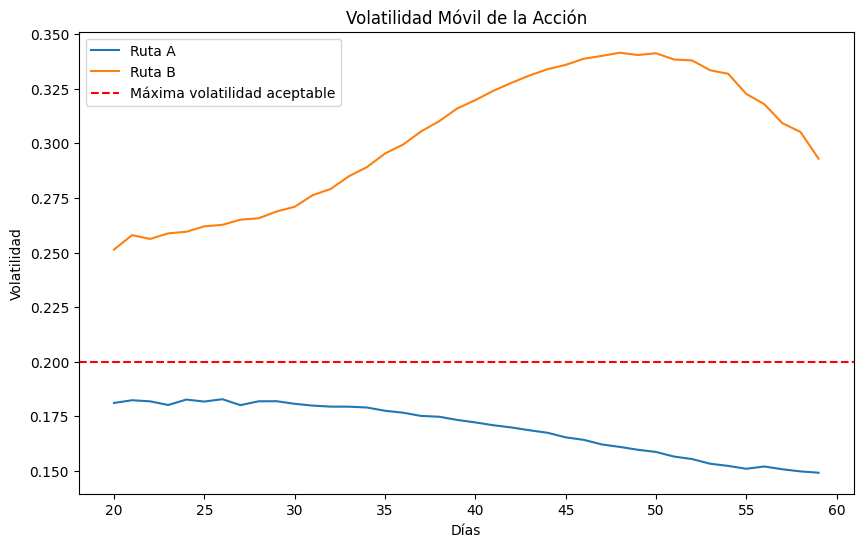

In [5]:
plt.figure(figsize=(10, 6))
plt.plot(range(20, 60), Desviaciones)
plt.axhline(y=0.2, color='r', linestyle='--', label='Máxima volatilidad aceptable')
plt.xlabel('Días')
plt.ylabel('Volatilidad')
plt.title('Volatilidad Móvil de la Acción')
plt.legend(['Ruta A', 'Ruta B', 'Máxima volatilidad aceptable'])
plt.show()

La Ruta A se mantiene debajo de la línea de 20% en todas sus ventanas mientras la Ruta B queda por encima en todo el periodo, de modo que la respuesta ya se puede leer en la gráfica antes de que la formalice en la celda siguiente.

### Corrección 2 — Decisión del contrato y respuesta escrita

**¿Cuál fue el error?** Mi cálculo terminaba en una lista de volatilidades que nunca comparé contra el límite, por lo que no respondí en cuál ruta se activa el contrato ni dejé la conclusión escrita en Markdown.

**¿Cuál es la corrección?** Convierto la lista en tabla y comparo el máximo de cada ruta contra 20%, ya que la condición de no exceder el límite debe cumplirse en todas las ventanas, y después imprimo la respuesta y la interpreto debajo.

**¿Por qué se cometió el error?** Me concentré en el cálculo y nunca traduje la pregunta del contrato a una condición concreta, con lo cual no tenía un punto de llegada que me indicara que el problema estaba resuelto.

**¿Cómo se puede evitar este error en el futuro?** Antes de programar voy a reescribir la pregunta como una condición de código, en este caso `máximo <= 0.20`, y a cerrar cada problema con una celda que imprima la respuesta en una oración, seguida de su Markdown.

In [6]:
Desviaciones = pd.DataFrame(Desviaciones)
if Desviaciones['Ruta A'].max() > 0.2:
    print("No se activa el contrato en la Ruta A.")
else:
    print("Se activa el contrato en la Ruta A.")

if Desviaciones['Ruta B'].max() > 0.2:
    print("No se activa el contrato en la Ruta B.")
else:
    print("se activa el contrato en la Ruta B.")

Se activa el contrato en la Ruta A.
No se activa el contrato en la Ruta B.


La Ruta A alcanza una volatilidad móvil máxima de 18.28% y nunca rebasa el límite, mientras que la Ruta B lo supera en sus 40 ventanas con un mínimo de 25.14%, por lo cual el contrato se activa únicamente en la Ruta A, aun cuando ambas rutas empiezan en 100 y terminan en 122.40, lo que confirma que la condición depende del camino y no del precio final.

---

## Problema 2

### Ingesta de Parámetros

In [7]:
S0, r, sigma, T, n, M, dt = 100, 0.05, 0.20, 1, 252, 10000, 1/252

### Corrección 3 — Simulación de los precios

**¿Cuál fue el error?** Mi celda calculaba `(r - 0.28**2/2)*dt * 0.28*np.sqrt(dt)*Z`, que multiplica la deriva por el choque en lugar de sumarlos y nunca usa `S0` ni el precio del día anterior, por lo que producía incrementos sueltos y no trayectorias de precio.

**¿Cuál es la corrección?** Creo una matriz de 10,000 trayectorias por 253 días con `S0` en la columna 0 y calculo cada día a partir del anterior con `paths[:, i] = paths[:, i - 1] * np.exp(...)`, sumando deriva y choque y sorteando un choque distinto para cada trayectoria.

**¿Por qué se cometió el error?** Partí de la forma vectorizada de los incrementos, en la que todo el horizonte se genera de una vez y la recurrencia queda implícita, de modo que al transcribirla perdí tanto el precio anterior como el signo entre los términos.

**¿Cómo se puede evitar este error en el futuro?** Voy a partir siempre del generador día por día que vimos en clase, que hace explícita la recurrencia, y a imprimir `paths[:3, :5]` antes de graficar para confirmar que la columna 0 vale `S0`, que los valores son precios y que las filas difieren entre sí.

In [8]:
np.random.seed(42)
paths = np.zeros((M, n + 1))
paths[:, 0] = S0

### Corrección 4 — Eventos por día

**¿Cuál fue el error?** Traté los tres eventos como un solo ciclo de los días 30 a 120 con una volatilidad fija de 0.28 que no aparece en el enunciado, sin distinguir cuándo cambia la tasa, cuándo cambia la volatilidad y cuándo ocurre la presentación.

**¿Cuál es la corrección?** Dentro del ciclo diario, tres condiciones asignan el valor de cada día, la tasa pasa a 8% desde el día 30, la volatilidad vale 40% del día 50 al 69 y del día 120 al 124 sumo un impulso diario aleatorio entre 1% y 3%.

**¿Por qué se cometió el error?** Pensé los eventos como un rango de días por recorrer y no como parámetros que cambian de valor según el día, por lo que no encontré un lugar en la fórmula donde cada evento pudiera entrar.

**¿Cómo se puede evitar este error en el futuro?** Antes de programar voy a escribir una tabla con evento, día de inicio, día de fin y valor, a traducir cada fila a una condición `inicio <= i < fin` y a comprobar con un `print` los días frontera, en este caso 29, 30, 49, 50, 69, 70, 119, 120, 124 y 125.

In [9]:
for i in range (1, n + 1):
    if i < 30:
        r = 0.05
    else:
        r = 0.08

    if 50 <= i < 70:
        sigma = 0.40
    else:
        sigma = 0.20

    if 120 <= i < 125:
        impulso = np.random.uniform(0.01, 0.03, M)
    else:
        impulso = 0
    
    paths[:, i] = paths[:, i - 1] * np.exp((r - 0.5 * sigma ** 2) * dt + sigma * np.sqrt(dt) * np.random.normal(0, 1, M) + impulso)

### Justificación de las modificaciones

**Tasa.** Subo la tasa a 8% a partir del día 30 y la uso como deriva porque la simulación se hace bajo la medida neutral al riesgo, en la que el activo crece en promedio a la tasa libre de riesgo.

**Volatilidad.** Fijo la volatilidad en 40% para los días 50 a 69, que son los 20 días posteriores a la junta, y la regreso a 20% en el día 70, mientras que el término $-\sigma^2/2$ lo calculo con la volatilidad de cada día para que el aumento de la dispersión no desplace la media.

**Impulso.** Como conozco la fecha de la presentación pero no la magnitud de la reacción, sorteo el impulso para cada trayectoria entre 1% y 3% diario durante la semana hábil del día 120 al 124, lo que equivale a un alza cercana a 10% en la semana, y lo sumo fuera del término multiplicado por `dt` porque ya es un rendimiento diario, con un rango que es un supuesto mío y que convendría estimar con reacciones históricas a anuncios similares.

In [10]:
paths[:3, :5]

array([[100.        , 100.63974344,  99.79499794, 100.24579329,
         97.78696534],
       [100.        ,  99.83783974,  99.4661498 ,  99.83371707,
         98.52727866],
       [100.        , 100.83135232, 100.08722901,  98.9250114 ,
         98.20776518]])

Con esta verificación confirmo que las trayectorias inician en 100 y se separan desde el primer día, de modo que cada escenario recibe choques distintos y la matriz contiene precios y no incrementos.

### Corrección 5 — Gráfica de trayectorias

**¿Cuál fue el error?** Grafiqué un histograma de los incrementos, que no muestra trayectorias contra el tiempo ni permite señalar en qué día ocurre cada cambio.

**¿Cuál es la corrección?** Grafico 20 trayectorias contra el día, con líneas verticales en los días 30, 50, 70, 120 y 125, que marcan el inicio y el final de cada evento.

**¿Por qué se cometió el error?** Grafiqué lo que producía la celda anterior en lugar de lo que pedía la entrega, porque no revisé los entregables contra la gráfica final.

**¿Cómo se puede evitar este error en el futuro?** Voy a copiar la lista de entregables del enunciado como checklist al inicio del notebook y a marcar cada punto al terminar, verificando en la gráfica el número de trayectorias y cada marcador pedido.

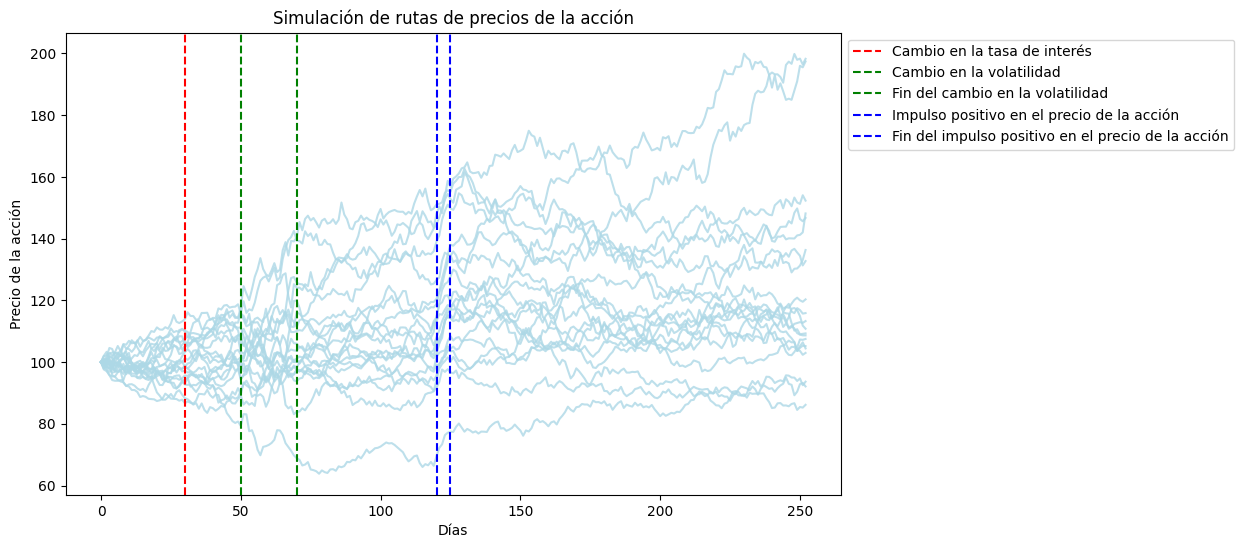

In [11]:
plt.figure(figsize=(10, 6))
plt.plot(paths[:20].T, color='lightblue', alpha=0.8)
plt.axvline(x=30, color='r', linestyle='--', label='Cambio en la tasa de interés')
plt.axvline(x=50, color='g', linestyle='--', label='Cambio en la volatilidad')
plt.axvline(x=70, color='g', linestyle='--', label='Fin del cambio en la volatilidad')
plt.axvline(x=120, color='b', linestyle='--', label='Impulso positivo en el precio de la acción')
plt.axvline(x=125, color='b', linestyle='--', label='Fin del impulso positivo en el precio de la acción')
plt.xlabel('Días')
plt.ylabel('Precio de la acción')
plt.title('Simulación de rutas de precios de la acción')
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.show()

En el día 30 no se aprecia un quiebre porque tres puntos más de tasa equivalen apenas a 0.012% de deriva diaria, entre los días 50 y 70 las trayectorias se separan con mayor rapidez por la volatilidad de 40%, y entre los días 120 y 125 casi todas suben al mismo tiempo, que es la señal de un evento común a todos los escenarios y no de un choque individual.

La dispersión ganada entre los días 50 y 70 no desaparece cuando la volatilidad regresa a 20%, ya que quedó incorporada en el nivel de los precios, por lo que un episodio temporal de volatilidad amplía de forma permanente el rango de precios posibles.

---

## Corrección general

### Corrección 6 — Interpretación en Markdown

**¿Cuál fue el error?** Entregué el examen sin interpretación ni justificación en Markdown, aunque el enunciado la hacía obligatoria para separar celdas, justificar cada modificación e interpretar los resultados.

**¿Cuál es la corrección?** Ahora cada resultado va seguido de su interpretación y cada modificación del problema 2 de su justificación, como muestro a lo largo de este notebook.

**¿Por qué se cometió el error?** Destiné todo el tiempo al código y dejé la redacción para el final, cuando ya no me quedaba margen para hacerla.

**¿Cómo se puede evitar este error en el futuro?** Al inicio del examen voy a crear las celdas de Markdown con encabezados y una línea pendiente por resultado, a llenarlas conforme obtengo cada uno y a reservar los últimos 10 minutos solo para revisarlas.

---

## Examen escrito — Autoevaluación

El examen escrito no se devolvió calificado, así que esta parte es una autoevaluación en la que respondo cada problema desde cero y, como no puedo confirmar qué contesté mal, en la primera pregunta de cada corrección señalo el punto donde mi respuesta original tenía más riesgo de perder puntos en lugar de un error confirmado.

### Corrección 7 — Payoffs de las tres trayectorias

El problema 1 da tres trayectorias que parten de 100 y terminan en 115, con K = 100, y pide los pagos call y put de las opciones europea, asiática y lookback de strike flotante, además de decir cuál de los tres tipos contiene más información sobre la trayectoria.

**¿Cuál fue el error?** No tengo el examen calificado, por lo que no puedo confirmar un error, pero el punto con más riesgo era decidir qué precios entran al cálculo, ya que si el promedio de la asiática o el mínimo de la lookback omiten el día 0, la call asiática de A pasa de 3.33 a 4 y la call lookback de C pasa de 15 a 5.

**¿Cuál es la corrección?** Calculo los seis pagos de cada trayectoria incluyendo el día 0 en el promedio, el máximo y el mínimo, que es la convención que usamos en clase al promediar toda la trayectoria, y uso K = 100 solo en la europea y la asiática, porque la lookback de strike flotante toma como strike el mínimo o el máximo del camino.

**¿Por qué se cometió el error?** Si lo hubo, la causa más probable es que el enunciado no dice si el día 0 forma parte de la trayectoria, y en un examen a mano es fácil tomar solo los cinco días que se mueven sin dejar escrita esa decisión.

**¿Cómo se puede evitar este error en el futuro?** Antes de calcular voy a escribir la convención en una línea, en este caso que el día 0 cuenta, y a revisar los pagos con dos reglas rápidas, que la put europea y la asiática valen cero cuando el precio final o el promedio superan el strike y que la call lookback nunca puede quedar debajo de la call europea, ya que el mínimo del camino incluye el precio inicial de 100, igual al strike.

**Respuesta.** Incluyo el día 0 en el promedio, el máximo y el mínimo, con call europea = máx(precio final − 100, 0), put europea = máx(100 − precio final, 0), call asiática = máx(promedio − 100, 0), put asiática = máx(100 − promedio, 0), call lookback = precio final − mínimo y put lookback = máximo − precio final.

| Día | A | B | C |
|---|---|---|---|
| 0 | 100 | 100 | 100 |
| 1 | 95 | 130 | 110 |
| 2 | 105 | 80 | 112 |
| 3 | 85 | 140 | 113 |
| 4 | 120 | 90 | 114 |
| 5 | 115 | 115 | 115 |

| Trayectoria | Promedio | Mínimo | Máximo | Call europea | Put europea | Call asiática | Put asiática | Call lookback | Put lookback |
|---|---|---|---|---|---|---|---|---|---|
| A | 103.33 | 85 | 120 | 15 | 0 | 3.33 | 0 | 30 | 5 |
| B | 109.17 | 80 | 140 | 15 | 0 | 9.17 | 0 | 35 | 25 |
| C | 110.67 | 100 | 115 | 15 | 0 | 10.67 | 0 | 15 | 0 |

Las tres trayectorias terminan en 115, por lo que la europea paga lo mismo en las tres y sus puts valen cero, mientras que la asiática premia a C, que sube de forma constante y mantiene el promedio más alto, y la lookback premia a B, cuyo recorrido entre 80 y 140 es el más amplio.

**¿Cuál de los tres tipos de opciones contiene más información sobre la trayectoria?** La asiática, porque su pago usa los seis precios del camino, mientras que la europea solo usa el precio final, que aquí es 115 en las tres trayectorias y por eso no las distingue, y la lookback usa el precio final y los dos extremos, de modo que registra qué tan lejos llegó el precio pero ignora el resto del recorrido, aunque por eso mismo es la que mejor refleja qué tan volátil fue el camino.

### Corrección 8 — Elección de opción según las Greeks

El problema 2 da tres opciones sobre la misma acción y pide elegir una para una subida sostenida y otra para un anuncio que puede provocar fuertes cambios, además de explicar qué significa que las Greeks sean sensibilidades locales.

**¿Cuál fue el error?** No tengo el examen calificado, por lo que no puedo confirmar un error, pero el punto con más riesgo era justificar cada elección con una sola griega, ya que la opción A es la que más gana con la subida por su Delta de 0.85 pero también la que más valor pierde con el tiempo, con el Theta más negativo de las tres.

**¿Cuál es la corrección?** Respondo cada escenario con la griega que lo gobierna, Delta para la subida sostenida y Vega para el anuncio, reviso las otras dos como costo de la elección y explico el carácter local de las Greeks con un ejemplo numérico de la tabla.

**¿Por qué se cometió el error?** Si lo hubo, la causa más probable es que la tabla invita a escoger el valor más alto de una columna y responder rápido, sin revisar qué cuesta esa elección en las otras columnas.

**¿Cómo se puede evitar este error en el futuro?** Para cada escenario voy a escribir primero qué variable cambia, el precio, la volatilidad o el tiempo, a elegir con la griega de esa variable y a cerrar la justificación con una frase sobre el costo en las otras dos.

**Respuesta.**

| Opción | Delta | Vega | Theta |
|---|---|---|---|
| A | 0.85 | 0.05 | −0.10 |
| B | 0.50 | 0.25 | −0.03 |
| C | 0.20 | 0.40 | −0.01 |

**Subida sostenida.** Elijo A, porque su Delta de 0.85 hace que gane cerca de 0.85 por cada peso que sube la acción, más que B y que C, y aunque su Theta de −0.10 es el más negativo, en una subida sostenida la ganancia por Delta compensa esa pérdida por el paso del tiempo.

**Anuncio con fuertes cambios.** Elijo C, porque su Vega de 0.40 es la más alta y el anuncio aumenta la volatilidad esperada, mientras que su Delta de 0.20 casi no la expone a la dirección del movimiento, que antes del anuncio no se conoce, y su Theta de −0.01 hace que esperar el anuncio cueste muy poco.

**Greeks como sensibilidades locales.** Cada griega mide cuánto cambia el valor de la opción ante un cambio pequeño en una sola variable, con las demás fijas y en el punto donde está hoy el mercado, de modo que si la acción sube un peso la opción A gana cerca de 0.85, pero si sube 20 pesos no gana exactamente 0.85 × 20 = 17, porque la Delta misma cambia conforme se mueve el precio y la aproximación deja de valer lejos del punto donde se calculó.

### Corrección 9 — Valor de Monte Carlo frente a un pago observado

El problema 3 parte de un valor de Monte Carlo de 15 con un intervalo de confianza de 95% de [14, 16] y de un pago observado de 80 seis meses después, y pregunta si la diferencia indica una mala implementación, qué mide el intervalo y si más simulaciones resolverían el problema.

**¿Cuál fue el error?** No tengo el examen calificado, por lo que no puedo confirmar un error, pero el punto con más riesgo era leer el intervalo [14, 16] como el rango donde debía caer el pago, cuando en realidad describe la precisión del promedio simulado.

**¿Cuál es la corrección?** Separo tres cosas que el enunciado pone juntas, el valor esperado que estima Monte Carlo, el pago del único escenario que ocurrió y el error de estimación que mide el intervalo, y respondo cada pregunta a partir de esa separación.

**¿Por qué se cometió el error?** Si lo hubo, la causa más probable es que el valor, el intervalo y el pago están en las mismas unidades, así que es fácil compararlos directamente sin preguntar si cada número es un promedio, un escenario o un error de estimación.

**¿Cómo se puede evitar este error en el futuro?** Antes de comparar dos números voy a etiquetar cada uno como promedio, escenario o error de estimación, y si no llevan la misma etiqueta no los comparo directamente.

**Respuesta.**

**¿La diferencia significa que la simulación estaba mal implementada?** No, porque 15 es el promedio descontado de los pagos de miles de escenarios y 80 es el pago de un solo escenario, el que ocurrió, de modo que una opción con valor esperado de 15 puede pagar 80 en un escenario favorable igual que puede pagar cero en otro, y la diferencia por sí sola no prueba un error de código, aunque sí obliga a revisar si la volatilidad histórica que usó el modelo representaba bien el riesgo de esos seis meses.

**¿Qué mide realmente el intervalo de confianza?** Mide la precisión con la que la simulación estimó el valor esperado, es decir, que si repitiera la simulación muchas veces, el 95% de los intervalos construidos así contendría el valor esperado del modelo, pero no dice nada sobre el rango en el que caerá el pago real, que depende de la dispersión de los escenarios y es mucho más amplio.

**¿Incrementar el número de simulaciones resolvería este problema?** No, porque más simulaciones solo angostan el intervalo alrededor de 15, ya que el error de Monte Carlo cae con la raíz del número de simulaciones y por eso cuadruplicarlas apenas lo reduce a la mitad, pero no cambian la dispersión de los pagos posibles ni corrigen los supuestos del modelo, de modo que si la volatilidad histórica estaba mal, más simulaciones darían un valor más preciso del mismo modelo equivocado.